In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from numba import jit
from PIL import Image
from numpy.polynomial import Polynomial as P
from scipy import ndimage
import copy

In [2]:
def Newton_Julia_log(poly,ylim,xlim,max_it=500,height=700,width=None,a=1,tol=1e-15,roots=True,conjugate=True,derivative=False,symmetry=False):
    if width is None:
        xint=xlim[1]-xlim[0]
        yint=ylim[1]-ylim[0]
        width=np.around((xint/yint)*height).astype(int)
    if roots:
        if conjugate: 
            poly=np.concatenate((poly,np.conjugate(poly)),axis=None)
        p=P.fromroots(poly)     
    if not(roots):
        p=P(poly)
    if derivative:
        p=p.deriv(1)
    dp=p.deriv(1)    
    Nf = lambda x : x-a*(p(x)/dp(x))
    x_imag, x_real = np.ogrid[ylim[1]: ylim[0]: height*1j, xlim[0]: xlim[1]: width*1j]
    z_array = x_real + x_imag*1j 
    p_0=np.absolute(p(z_array))
    p_1=copy.deepcopy(p_0)
    i_to_convergence=np.zeros([height,width]) #height*width array of all zeros
    log_smooth=np.zeros([height,width])
    log_tol=np.log(tol)
    z_values=np.zeros([height,width]).astype('complex128') #height*width array of all zeros
    already_converged=p_0<tol 
    for i in np.arange(max_it):
        not_already_converged=np.invert(already_converged)
        z_array[not_already_converged]=Nf(z_array[not_already_converged])
        p_1[not_already_converged]=np.absolute(p(z_array[not_already_converged]))
        converging=p_1<tol
        converging=np.bitwise_and(converging,not_already_converged)
        i_to_convergence[converging]=i+1
        log_smooth[converging]=(log_tol-np.log(p_0[converging]))/(np.log(p_1[converging])-np.log(p_0[converging]))
        z_values[converging]=z_array[converging]
        already_converged=np.bitwise_or(converging,already_converged)
        p_0=copy.deepcopy(p_1)
    if symmetry and ylim[0]==0 and ylim[1]>0 and roots and conjugate and np.imag(a)==0:
        i_to_convergence2=i_to_convergence[::-1,:][1:,:]
        log_smooth2=log_smooth[::-1,:][1:,:]
        z_values2=np.conjugate(z_values[::-1,:][1:,:])
        i_to_convergence=np.concatenate((i_to_convergence,i_to_convergence2),axis=0)
        log_smooth=np.concatenate((log_smooth,log_smooth2),axis=0)
        z_values=np.concatenate((z_values,z_values2),axis=0)

    return i_to_convergence, log_smooth, z_values

In [3]:
def Newton_C_Brot_log(poly,ylim,xlim,max_it=500,height=700,width=None,a=1,tol=1e-15,conjugate=True,conj_c=False,z0=0):
    if width is None:
        xint=xlim[1]-xlim[0]
        yint=ylim[1]-ylim[0]
        width=np.around((xint/yint)*height).astype(int)
    if conjugate: 
        poly=np.concatenate((poly,np.conjugate(poly)),axis=None)
    p=P.fromroots(poly)     
    dp=p.deriv(1)
    x_imag, x_real = np.ogrid[ylim[1]: ylim[0]: height*1j, xlim[0]: xlim[1]: width*1j]
    c_array = x_real + x_imag*1j
    if conj_c:
        c_array_bar=np.conjugate(c_array)
        p_c=lambda x,ind : p(x[ind])*(x[ind]-c_array[ind])*(x[ind]-c_array_bar[ind])
        dp_c=lambda x,ind : dp(x[ind])*(x[ind]-c_array[ind])*(x[ind]-c_array_bar[ind])+p(x[ind])*(x[ind]-c_array[ind])+p(x[ind])*(x[ind]-c_array_bar[ind])
    if not(conj_c):
        p_c=lambda x,ind : p(x[ind])*(x[ind]-c_array[ind])
        dp_c=lambda x,ind : dp(x[ind])*(x[ind]-c_array[ind])+p(x[ind])
    Nf = lambda x,ind : x[ind]-a*(p_c(x,ind)/dp_c(x,ind))
    z_array=z0*np.ones([height,width]).astype('complex128')
    p_0=np.zeros([height,width])
    p_0[p_0==0]=np.absolute(p_c(z_array,p_0==0))
    p_1=copy.deepcopy(p_0)
    i_to_convergence=np.zeros([height,width]) #height*width array of all zeros
    log_smooth=np.zeros([height,width])
    log_tol=np.log(tol)
    z_values=np.zeros([height,width]).astype('complex128') #height*width array of all zeros
    already_converged=p_0<tol 
    for i in np.arange(max_it):
        not_already_converged=np.invert(already_converged)
        z_array[not_already_converged]=Nf(z_array,not_already_converged)
        p_1[not_already_converged]=np.absolute(p_c(z_array,not_already_converged))
        converging=p_1<tol
        converging=np.bitwise_and(converging,not_already_converged)
        i_to_convergence[converging]=i+1
        log_smooth[converging]=(log_tol-np.log(p_0[converging]))/(np.log(p_1[converging])-np.log(p_0[converging]))
        z_values[converging]=z_array[converging]
        already_converged=np.bitwise_or(converging,already_converged)
        p_0=copy.deepcopy(p_1)

    return i_to_convergence, log_smooth, z_values

In [4]:
def Newton_A_Brot_log(poly,ylim=[(-2**.5)/2,(2**.5)/2],xlim=[1-(2**.5)/2,1+(2**.5)/2],max_it=500,height=700,width=None,tol=1e-15,roots=True,conjugate=True,z0=0):
    if width is None:
        xint=xlim[1]-xlim[0]
        yint=ylim[1]-ylim[0]
        width=np.around((xint/yint)*height).astype(int)
    if roots:
        if conjugate: 
            poly=np.concatenate((poly,np.conjugate(poly)),axis=None)
        p=P.fromroots(poly)
    if not(roots):
        p=P(poly)
    dp=p.deriv(1)
    x_imag, x_real = np.ogrid[ylim[1]: ylim[0]: height*1j, xlim[0]: xlim[1]: width*1j]
    a_array = x_real + x_imag*1j
    Nf = lambda x,ind : x[ind]-a_array[ind]*(p(x[ind])/dp(x[ind]))
    z_array=z0*np.ones([height,width]).astype('complex128')
    p_0=np.absolute(p(z_array))
    p_1=copy.deepcopy(p_0)
    i_to_convergence=np.zeros([height,width]) #height*width array of all zeros
    log_smooth=np.zeros([height,width])
    log_tol=np.log(tol)
    z_values=np.zeros([height,width]).astype('complex128') #height*width array of all zeros
    already_converged=p_0<tol 
    for i in np.arange(max_it):
        not_already_converged=np.invert(already_converged)
        z_array[not_already_converged]=Nf(z_array,not_already_converged)
        p_1[not_already_converged]=np.absolute(p(z_array[not_already_converged]))
        converging=p_1<tol
        converging=np.bitwise_and(converging,not_already_converged)
        i_to_convergence[converging]=i+1
        log_smooth[converging]=(log_tol-np.log(p_0[converging]))/(np.log(p_1[converging])-np.log(p_0[converging]))
        z_values[converging]=z_array[converging]
        already_converged=np.bitwise_or(converging,already_converged)
        p_0=copy.deepcopy(p_1)

    return i_to_convergence, log_smooth, z_values

In [5]:
def rand_poly_roots(degree,xlim=[-1,1],ylim=[-1,1],seed=None):
    if seed is not None:
        np.random.seed(seed)
    x=xlim[0]+(xlim[1]-xlim[0])*np.random.uniform(size=degree)
    y=ylim[0]+(ylim[1]-ylim[0])*np.random.uniform(size=degree)
    return x+y*1j
    

In [6]:
def Newton_Iterations_Image(I,cmap,return_image=True,save_image=None,transformation=None,replace_zeros=False,**kwargs):
    if replace_zeros:
        I[I==0]=np.max(I)
    if transformation is not None:
        I=transformation(I)
    m=np.min(I)
    M=np.max(I)
    I_scaled=(I-m)/(M-m)
    if bool(kwargs):
        I_scaled=ndimage.median_filter(I_scaled, **kwargs)        
    im=Image.fromarray(np.around(cmap(I_scaled)*255).astype(np.uint8)).convert("RGBA")
    if save_image is not None:
        im.save(save_image)
    if return_image:
        return im


In [7]:
def Newton_Image_Combine(I_front,cmap_front,alpha,I_back=None,cmap_back=None,return_image=True,save_image=None,**kwargs):
    if cmap_back is None:
        cmap_back=cmap_front
    m_a=np.min(alpha)
    M_a=np.max(alpha)
    alpha_scaled=(alpha-m_a)/(M_a-m_a)
    if bool(kwargs):
        alpha_scaled=ndimage.median_filter(alpha_scaled, **kwargs)        
    im_alpha=Image.fromarray(np.around(alpha_scaled*255).astype(np.uint8)).convert("L")
    im_front=Newton_Iterations_Image(I_front,cmap_front,**kwargs)
    im_front.putalpha(im_alpha)
    if I_back is None:
        im_back=Image.new("RGBA",I_front.shape,"black")
    if I_back is not None:
        im_back=Newton_Iterations_Image(I_back,cmap_back,**kwargs)
    im=Image.alpha_composite(im_back,im_front)
    if save_image is not None:
        im.save(save_image)
    if return_image:
        return im
    

In [8]:
def cdf_color(I):
    uniq=np.unique(I,return_counts=True,return_inverse=True)
    cdf_vals=np.cumsum(uniq[2])/sum(uniq[2])
    I_cdf=np.reshape(cdf_vals[uniq[1]],newshape=I.shape)
    return I_cdf


In [9]:
def replace_zero(I):
    M=np.max(I)
    I[I==0]=M
    return I

In [10]:
def iteration_hist(I):
    uniq=np.unique(I,return_counts=True)
    plt.bar(uniq[0],uniq[1]/np.sum(uniq[1]))
    plt.show()

In [11]:
def cmap_plot(I):
    uniq=np.unique(I,return_counts=True)
    Percentage_Data=np.cumsum(uniq[1])/np.sum(uniq[1])
    M=np.max(uniq[0])
    m=np.min(uniq[0])
    Percentage_Cmap=(uniq[0]-m)/(M-m)
    plt.plot(Percentage_Data,Percentage_Cmap)
    plt.show()


In [31]:
TI,TL,TZ=Newton_Julia_log(rand_poly_roots(7,seed=0),ylim=[0,.2],xlim=[-.3,.3],max_it=500,height=1000,a=1.4,tol=1e-15,symmetry=True)

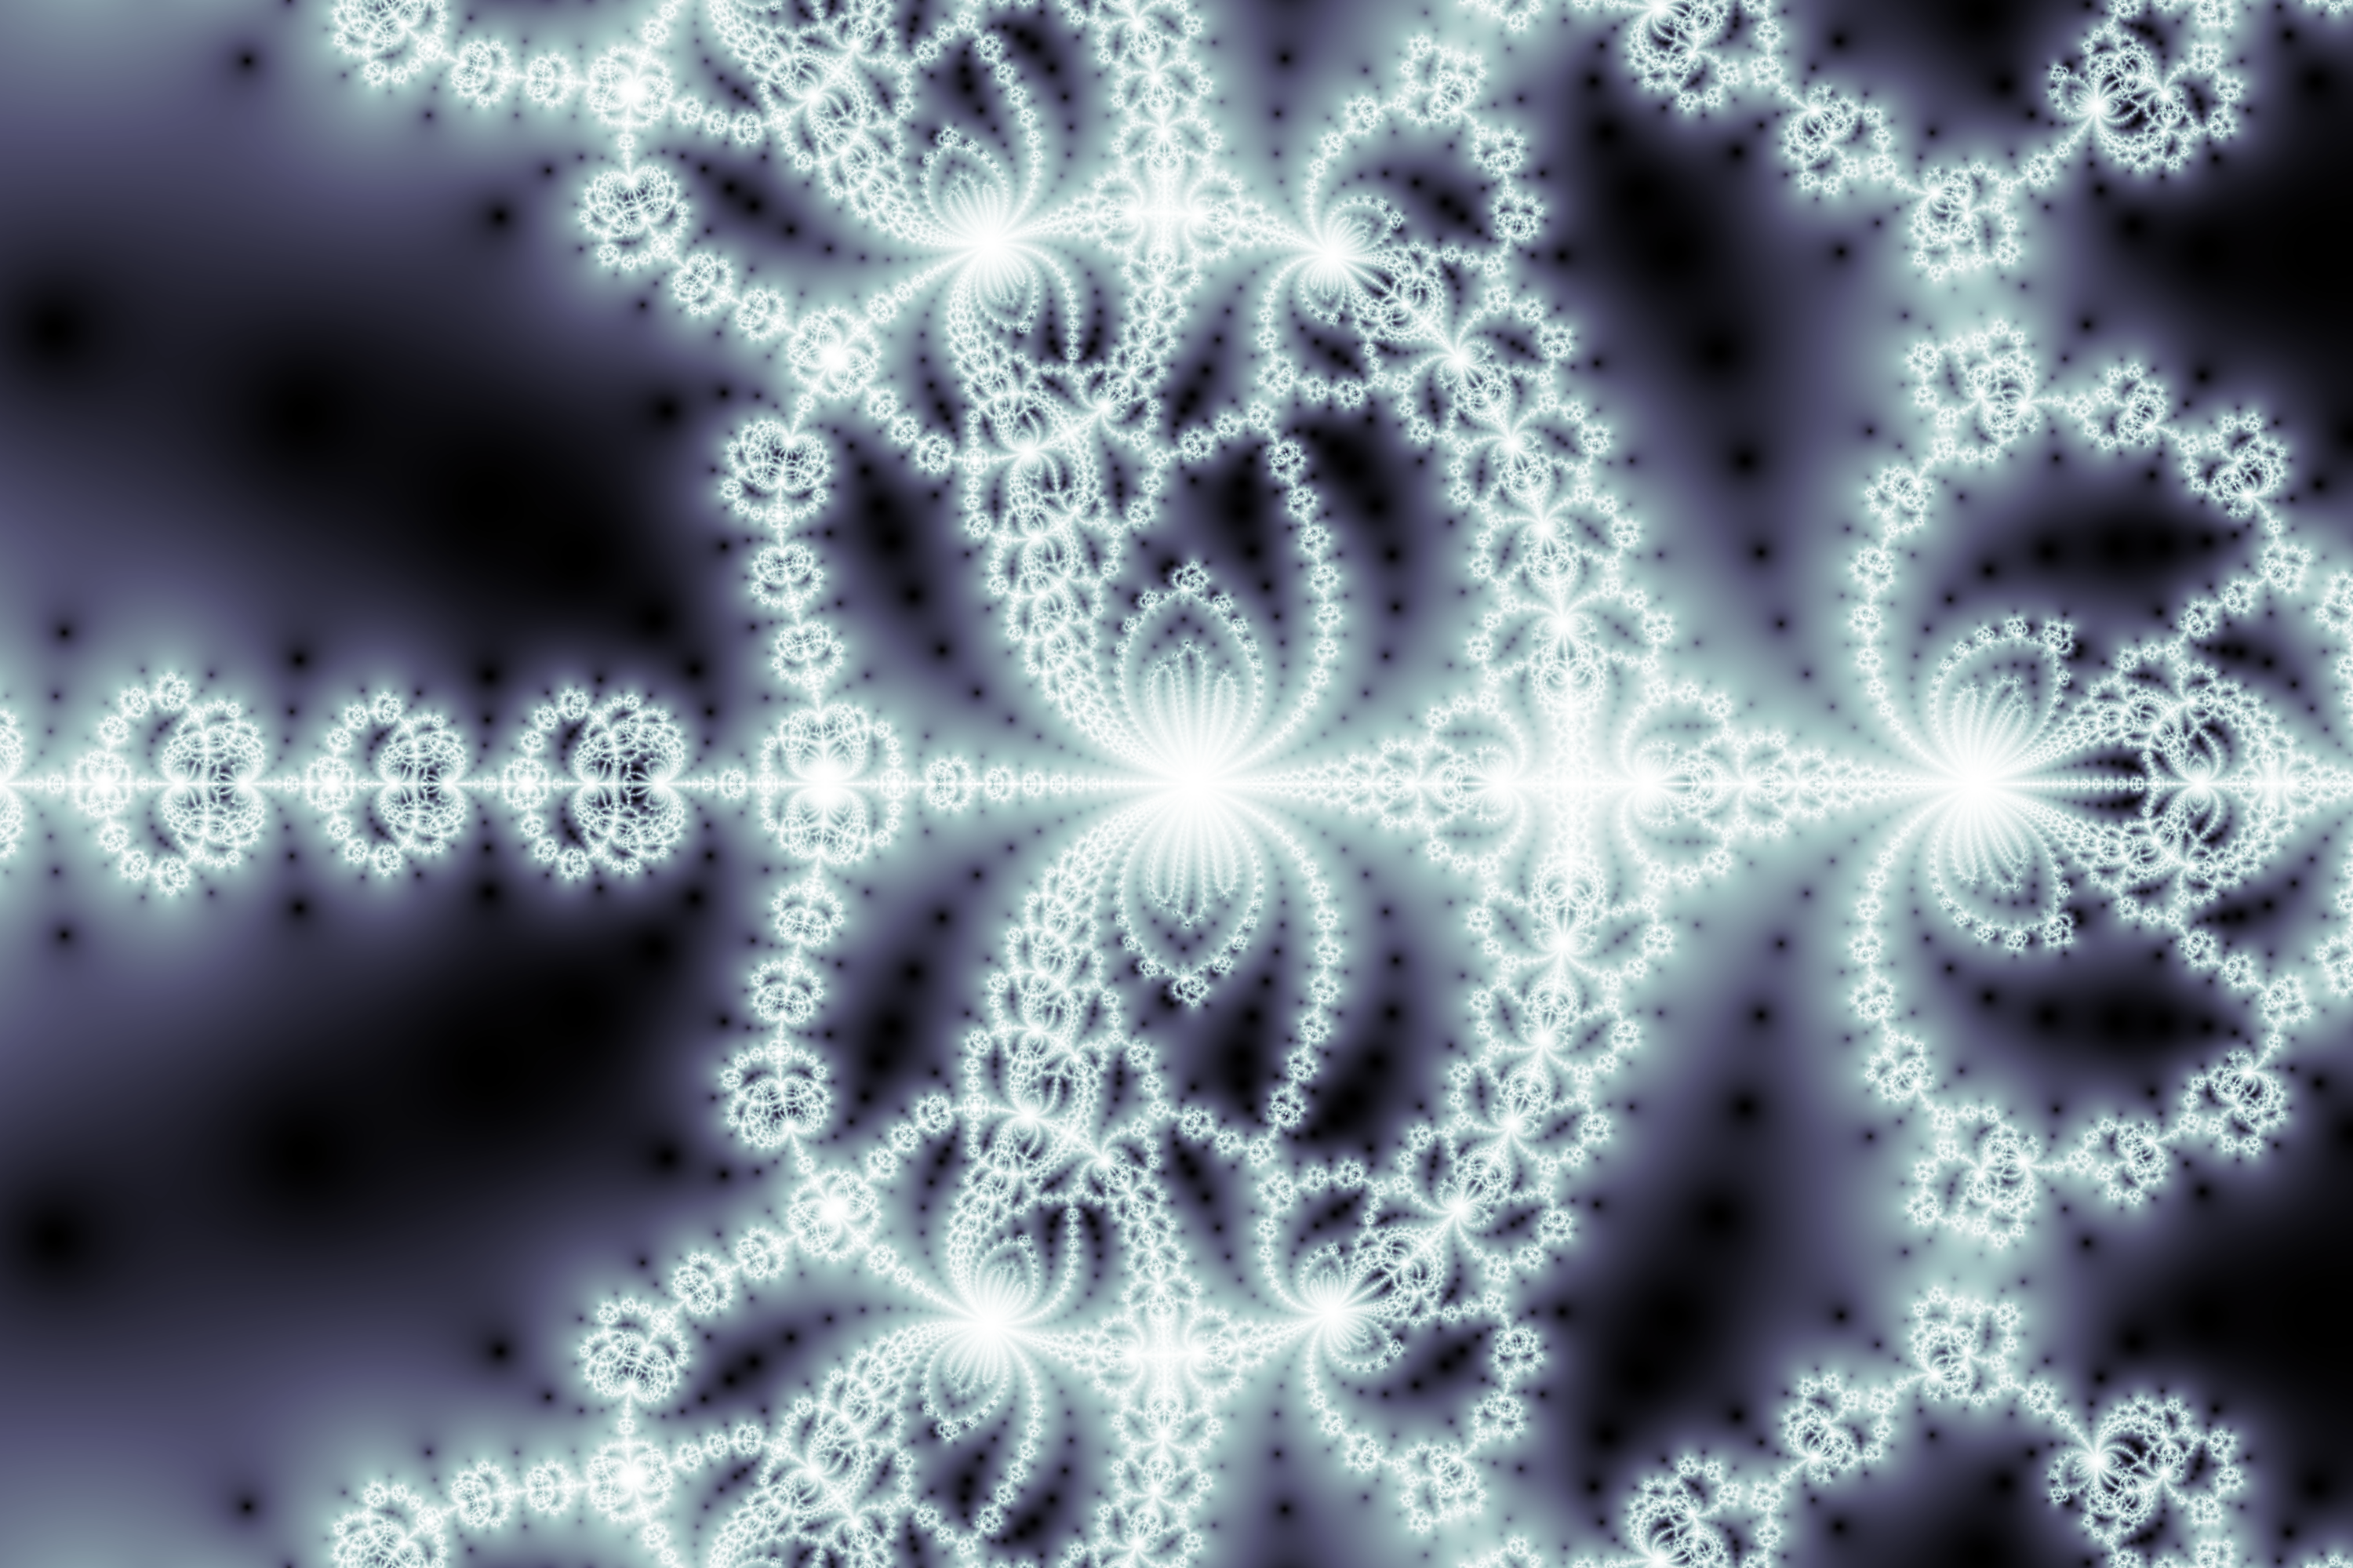

In [32]:
Newton_Iterations_Image(cdf_color(TI+TL),cmap=matplotlib.colormaps['bone'],size=3)

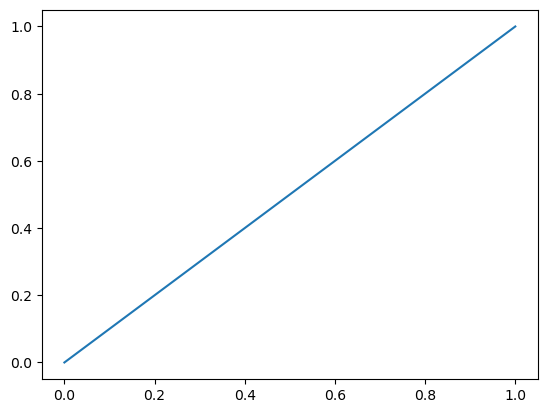

In [33]:
cmap_plot(cdf_color(TI+TL))

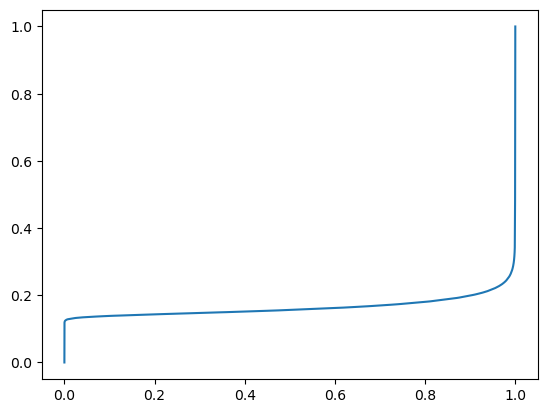

In [34]:
cmap_plot(TI+TL)

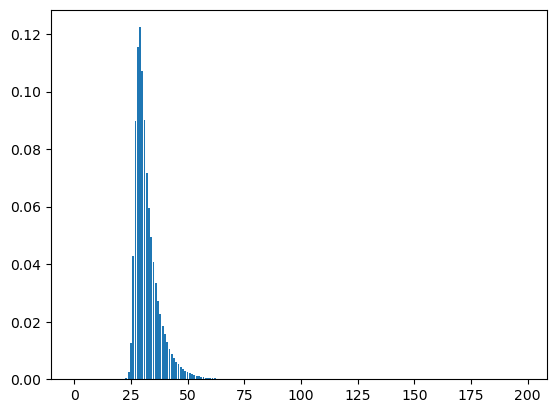

In [35]:
iteration_hist(TI)